## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Please read the instructions carefully before starting the project.**

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

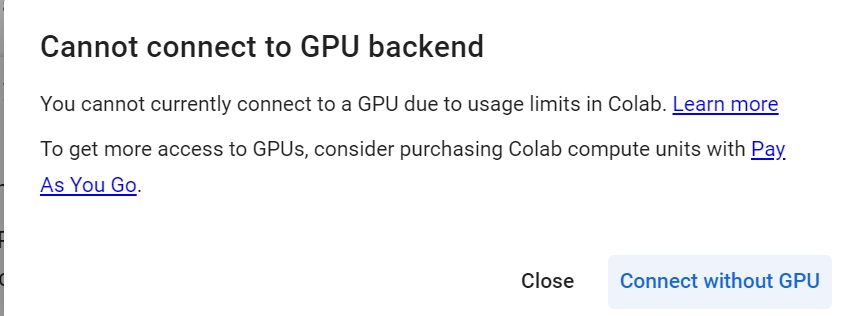

## **Installing and Importing Necessary Libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U scikit-learn sentence-transformers gensim transformers tqdm -q

In [2]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

## **Loading the dataset**

In [3]:
# uncomment and run the following code if Google Colab is being used and the dataset is in Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Loading the dataset
stock_news = pd.read_csv("/content/drive/MyDrive/PGP-AIML/Natural Language Processing/Project/stock_news.csv")

In [5]:
# Creating a copy of the dataset
stock = stock_news.copy()

## **Data Overview**

### Displaying the first few rows of the dataset

In [6]:
stock.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


### Understanding the shape of the dataset

In [7]:
stock.shape

(349, 8)

**Observations:** There are 349 records and 8 columns.

### Checking the data types of the columns

In [8]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


**Observations:**
- 2 Columns are of data type Object.
- 4 Columns are of data type float64
- 2 Columns are of data type int64

In [9]:
# To convert the 'Date' column in the 'stock' DataFrame to datetime format.
stock['Date'] = pd.to_datetime(stock['Date'])

### Checking the statistical summary

In [10]:
stock.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,349,2019-02-16 16:05:30.085959936,2019-01-02 00:00:00,2019-01-14 00:00:00,2019-02-05 00:00:00,2019-03-22 00:00:00,2019-04-30 00:00:00,NaN
Open,349.0,46.229233,37.567501,41.740002,45.974998,50.7075,66.817497,6.442817
High,349.0,46.700458,37.817501,42.244999,46.025002,50.849998,67.0625,6.507321
Low,349.0,45.745394,37.305,41.482498,45.639999,49.7775,65.862503,6.391976
Close,349.0,44.926317,36.254131,40.246914,44.596924,49.11079,64.805229,6.398338
Volume,349.0,128948236.103152,45448000.0,103272000.0,115627200.0,151125200.0,244439200.0,43170314.918964
Label,349.0,-0.054441,-1.0,-1.0,0.0,0.0,1.0,0.715119


In [11]:
stock.columns.tolist()

['Date', 'News', 'Open', 'High', 'Low', 'Close', 'Volume', 'Label']

In [12]:
stock.nunique()

,0
Date,71
News,349
Open,70
High,70
Low,71
Close,71
Volume,71
Label,3


### Checking the duplicate values

In [13]:
stock.duplicated().sum()

0

### Checking for missing values

In [14]:
stock.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


**Observations:** There are no missing values

## **Exploratory Data Analysis**

### Univariate Analysis

* Distribution of individual variables
* Compute and check the distribution of the length of news content

#### Observations on Label

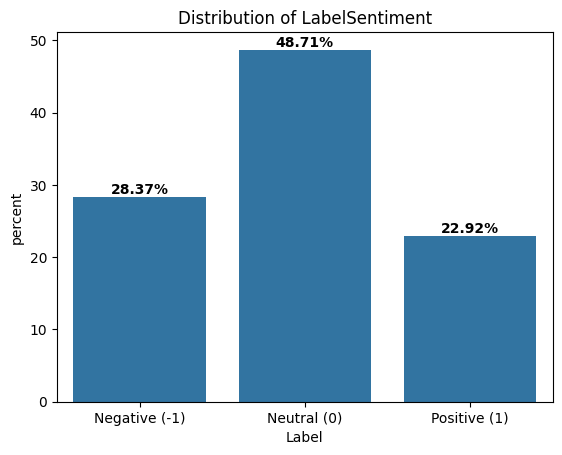

In [15]:
# Define label mapping
label_mapping = {0: "Neutral (0)", 1: "Positive (1)", -1: "Negative (-1)"}

# Convert 'Label' column to categorical type with the desired order
stock["Label"] = stock["Label"].map(label_mapping)

ax = sns.countplot(data=stock, x="Label", stat="percent");
ax.set_title("Distribution of LabelSentiment");

for p in ax.patches:
    percentage = f"{p.get_height():.2f}%"  # Format percentage
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

**Observations:**
- 48.71% of labels are Neutral
- 28.37% of labels are Negative
- 22.92% of labels are Positive

#### Density Plot of Price (Open,High,Low,Close)

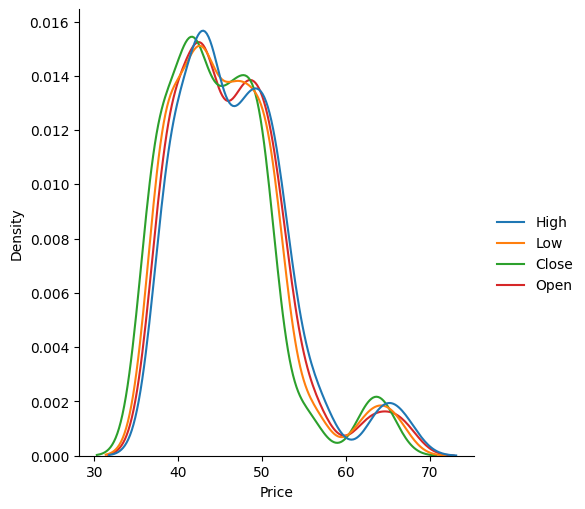

In [16]:
g = sns.displot(data=stock[['High', 'Low', 'Close', 'Open']], kind="kde", palette="tab10")
g.set_axis_labels("Price", "Density")
plt.show()

#### Observations on Volume

In [ ]:
sns.histplot(stock, x='Volume', bins=30, kde=True)

#### Observations on News length

In [ ]:
#Calculating the total number of words present in the news content.
stock['news_len'] = stock['News'].apply(lambda x: len(x.split(' ')))


stock['news_len'].describe().T

In [ ]:
sns.histplot(data=stock,x="news_len",kde=True);

**Observations:**
- Length of the news articles is Left skewed.
- There are 349 observations in the dataset.
- The mean news_len is 49.31, indicating that, on average, news articles in this dataset contain around 49 words.
- The standard deviation (5.73) suggests that most news lengths are fairly close to the mean, with some variation.
- The shortest news piece has 19 words, while the longest one has 61, indicating a moderate spread in length.
- 25% of the news articles are 46 words or fewer in length.
- 50% (Median) of the news articles have a length of 50, which is close to the mean, indicating a somewhat symmetric distribution.
- 75% of the articles are 53 or shorter, meaning that a quarter of the articles have a length between 53 and 61.


### Bivariate Analysis

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

In [ ]:
# Select only the numeric columns from the stocknews_df DataFrame
numeric_columns = stock.select_dtypes(include='number')

# Plot the correlation matrix fir the numeric columns
plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_columns.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)

# Set plot labels and title
plt.title('Correlation Matrix for Numeric Columns')
plt.show()


**Observations:**
*   *Price Correlation:* The opening, high, low, and closing stock prices all move together, which is why they’re very closely related. This makes sense since they’re just diﬀerent measures of the same stock’s price.
*   *Volume and News Length:* The trading volume and the length of news articles don’t seem to follow the same pattern as the other numbers, so they don’t show a strong relationship with the rest of the data.



#### Label vs Price (Open, High, Low, Close)

In [ ]:
plt.figure(figsize=(10, 8))

for i, variable in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=stock, x="Label", y=variable)
    plt.tight_layout(pad=2)

plt.show()

#### Label vs Volume

In [ ]:
# Boxplot of Label vs Volume
sns.boxplot(
    data=stock, x="Label", y="Volume"
)

#### Date vs Price (Open, High, Low, Close)

In [ ]:
stock_daily = stock.groupby('Date').agg(
    {
        'Open': 'mean',
        'High': 'mean',
        'Low': 'mean',
        'Close': 'mean',
        'Volume': 'mean',
    }
).reset_index()  # Group the 'stocks' DataFrame by the 'Date' column

stock_daily.set_index('Date', inplace=True)
stock_daily.head()

In [ ]:
# Lineplot of all the variables except Volume
plt.figure(figsize=(15,5))
sns.lineplot(stock_daily.drop("Volume", axis=1));

#### Volume vs Close Price

In [ ]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Close', ax=ax1, color='blue', marker='o', label='Close Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));

## **Data Preprocessing**

####Statistical Summary

In [ ]:
# Statistical summary of the 'Date' column
stock["Date"].describe()

In [ ]:
# Ensure the 'Date' column is in datetime format
stock['Date'] = pd.to_datetime(stock['Date'])

# Extract relevant date components for summarization
stock['Year'] = stock['Date'].dt.year
stock['Month'] = stock['Date'].dt.month
stock['Day'] = stock['Date'].dt.day

# Print the statistical summary of the 'Date' column components
print("Year Summary:")
print(stock['Year'].describe())
print("\nMonth Summary:")
print(stock['Month'].describe())
print("\nDay Summary:")
print(stock['Day'].describe())

**Observations:**
- All entries in the dataset are from the year 2019.
- The entries are concentrated in the first four months of the year, with a significant number of entries from January and February.
- The entries are spread throughout the days of the month, with a relatively even distribution.

### Train-test-validation Split

In [ ]:
# Select all rows where the 'Date' is before '2019-04-01'
X_train = stock[(stock['Date'] < '2019-04-01')].reset_index()

# Select all rows where the 'Date' is from '2019-04-01 to '2019-04-16' (excluded)
X_val = stock[(stock['Date'] >= '2019-04-01') & (stock['Date'] < '2019-04-16')].reset_index()

# Select all rows where the 'Date' is from '2019-04-16' till the end.
X_test = stock[stock['Date'] >= '2019-04-16'].reset_index()

In [ ]:
# Set 'Label' column as the target variable
y_train = X_train["Label"].copy()
y_val = X_val["Label"].copy()
y_test = X_test["Label"].copy()

In [ ]:
# Print the shape of X_train,X_val,X_test,y_train,y_val and y_test
print("Train data shape: ",X_train.shape)
print("Validation data shape: ",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape: ",y_train.shape)
print("Validation label shape: ",y_val.shape)
print("Test label shape: ",y_test.shape)

## **Word Embeddings**

### Word2Vec

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in stock['News'].values]

In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Let's check out a few word embeddings obtained using the model.

In [ ]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

In [ ]:
# Checking the word embedding of a random word
word = "economy"
model_W2V.wv[word]

In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_wv = pd.DataFrame(X_train["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

In [ ]:
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)

### GloVe

In [ ]:
# load the Stanford GloVe model
filename = "/content/drive/MyDrive/PGP-AIML/Natural Language Processing/Project/glove.6B.100d.txt.word2vec"
glove_model = KeyedVectors.load_word2vec_format(filename, binary=False)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

Let's check out a few word embeddings.

In [ ]:
# Checking the word embedding of a random word
word = "stock"
glove_model[word]

In [ ]:
# Checking the word embedding of a random word
word = "economy"
glove_model[word]

In [ ]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [ ]:
vec_size=100

In [ ]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_gl = pd.DataFrame(X_train["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_gl = pd.DataFrame(X_val["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_gl = pd.DataFrame(X_test["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

In [ ]:
# Print the shapes of the final dataframes
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape)

### Sentence Transformer

#### Defining the model

In [ ]:
#Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

#### Encoding the dataset

In [ ]:
# setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Encoding the dataset
start = time.time()

# Apply Sentence Transformer on 'News' column
X_train_st = model.encode(X_train["News"].values, show_progress_bar=True, device=device)

# Apply Sentence Transformer on 'News' column
X_val_st = model.encode(X_val["News"].values, show_progress_bar=True, device=device)

# Apply Sentence Transformer on 'News' column
X_test_st = model.encode(X_test["News"].values, show_progress_bar=True, device=device)

end = time.time()
print("Time taken ",(end-start))

In [ ]:
# Print the shapes of the final dataframes
print(X_train_st.shape, X_val_st.shape, X_test_st.shape)

[INFO]: Each news content has been converted to a 384-dimensional vector.

In [ ]:
# Print the device being used
print(f"Using device: {device}")

## **Sentiment Analysis**

### Model Evaluation Criterion

All model performance data is tabulated in the Model Summary section at the end of the Sentiment Analysis section.  

### Utility Functions

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    acc = accuracy_score(target, pred)  # Compute Accuracy.
    recall = recall_score(target, pred,average='weighted')  # Compute Recall.
    precision = precision_score(target, pred,average='weighted')  # Compute Precision.
    f1 = f1_score(target, pred,average='weighted')  # Compute F1-score.

    # Create a DataFrame to store the computed metrics.
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf  # Return the DataFrame with the metrics.

### Base Model - Word2Vec

In [ ]:
# Building the model

#Uncomment only one of the snippets related to fitting the model to the data

#base_wv = GradientBoostingClassifier(random_state = 42)
base_wv = RandomForestClassifier(random_state=42)
#base_wv = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_wv, y_train)

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(base_wv,X_train_wv,y_train)

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(base_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_wv = model_performance_classification_sklearn(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

In [ ]:
#Calculating different metrics on validation data
base_val_wv = model_performance_classification_sklearn(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

### Base Model - GloVe

In [ ]:
# Building the model

#base_gl = GradientBoostingClassifier(random_state=42)
base_gl = RandomForestClassifier(random_state=42)
#base_gl = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_gl.fit(X_train_gl, y_train)

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(base_gl,X_train_gl,y_train)

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(base_gl,X_val_gl,y_val)

In [ ]:
# Calculating different metrics on training data

# Compute the model performance for the training data
base_train_gl=model_performance_classification_sklearn(base_gl,X_train_gl,y_train)
print("Training performance:\n", base_train_gl)

In [ ]:
# Calculating different metrics on validation data

# Compute the model performance for the validation data
base_val_gl = model_performance_classification_sklearn(base_gl,X_val_gl,y_val)
print("Validation performance:\n",base_val_gl)

### Base Model - Sentence Transformer

In [ ]:
# Building the model

#base_st = GradientBoostingClassifier(random_state=42)
base_st = RandomForestClassifier(random_state=42)
#base_st = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_st.fit(X_train_st, y_train) #Complete the code to fit the chosen model on the

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(base_st,X_train_st,y_train)

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(base_st,X_val_st,y_val)

In [ ]:
# Calculating different metrics on training data

# Compute the model performance for the training data
base_train_st=model_performance_classification_sklearn(base_st,X_train_st,y_train)
print("Training performance:\n", base_train_st)

In [ ]:
#Calculating different metrics on validation data

# Compute the model performance for the validation data
base_val_st = model_performance_classification_sklearn(base_st,X_val_st,y_val)
print("Validation performance:\n",base_val_st)

### Tuned Model - Word2Vec

In [ ]:
start = time.time()

# Choose the type of classifier.

#tuned_wv = GradientBoostingClassifier(random_state=42)
tuned_wv = RandomForestClassifier(random_state=42)
#tuned_wv = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_wv = grid_obj.best_estimator_

In [ ]:
# Fit the best algorithm to the data.
tuned_wv.fit(X_train_wv, y_train)

In [ ]:
plot_confusion_matrix(tuned_wv,X_train_wv,y_train)

In [ ]:
plot_confusion_matrix(tuned_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_wv=model_performance_classification_sklearn(tuned_wv,X_train_wv,y_train)
print("Training performance:\n",tuned_train_wv)

In [ ]:
#Calculating different metrics on validation data
tuned_val_wv = model_performance_classification_sklearn(tuned_wv,X_val_wv,y_val)
print("Validation performance:\n",tuned_val_wv)

### Tuned Model - GloVe

In [ ]:
start = time.time()

#tuned_gl = GradientBoostingClassifier(random_state=42)
tuned_gl = RandomForestClassifier(random_state=42)
#tuned_gl = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_gl, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_gl, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_gl = grid_obj.best_estimator_

In [ ]:
# Fit the best algorithm to the data.
tuned_gl.fit(X_train_gl, y_train)

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(tuned_gl,X_train_gl,y_train)

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(tuned_gl,X_val_gl,y_val)

In [ ]:
#Calculating different metrics on training data

# Compute the model performance for the training data
tuned_train_gl=model_performance_classification_sklearn(tuned_gl,X_train_gl,y_train)
print("Training performance:\n",tuned_train_gl)

In [ ]:
#Calculating different metrics on validation data

# Compute the model performance for the validation data
tuned_val_gl = model_performance_classification_sklearn(tuned_gl,X_val_gl,y_val)
print("Validation performance:\n",tuned_val_gl)

### Tuned Model - Sentence Transformer

In [ ]:
start = time.time()

# Choose the type of classifier.

#tuned_st = GradientBoostingClassifier(random_state=42)
tuned_st = RandomForestClassifier(random_state=42)
#tuned_st = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_st, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_st = grid_obj.best_estimator_

In [ ]:
# Fit the best algorithm to the data.
tuned_st.fit(X_train_st, y_train)

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(tuned_st,X_train_st,y_train)

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(tuned_st,X_val_st,y_val)

In [ ]:
#Calculating different metrics on training data

# Compute the model performance for the training data
tuned_train_st=model_performance_classification_sklearn(tuned_st,X_train_st,y_train)
print("Training performance:\n",tuned_train_st)

In [ ]:
#Calculating different metrics on validation data

# Compute the model performance for the validation data
tuned_val_st = model_performance_classification_sklearn(tuned_st,X_val_st,y_val)
print("Validation performance:\n",tuned_val_st)

### Model Performance Summary and Final Model Selection

In [ ]:
#training performance comparison

models_train_comp_df = pd.concat(
    [base_train_wv.T,
     base_train_gl.T,
     base_train_st.T,
     tuned_train_wv.T,
     tuned_train_gl.T,
     tuned_train_st.T,
    ],axis=1
)

models_train_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Training performance comparison:")
models_train_comp_df

In [ ]:
#validation performance comparison

models_val_comp_df = pd.concat(
    [base_val_wv.T,
     base_val_gl.T,
     base_val_st.T,
     tuned_val_wv.T,
     tuned_val_gl.T,
     tuned_val_st.T,
     ],axis=1
)

models_val_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Validation performance comparison:")
models_val_comp_df

### Model Summary & Observations

**Best Metric for Evaluation:**

For sentiment analysis, F1-score is the most important metric because:

-   It balances precision (how many predicted positives are actually positive) and recall (how many actual positives are correctly identified).
-   In cases where class distribution may be imbalanced, accuracy alone can be misleading.

**Best Model Selection:**

As you have seen above after evaulating all models we have determined that Tuned Random Forest with GloVe Embeddings is the best model because:

-   Highest validation F1-score (0.5306).
-   Better generalization than Gradient Boosting and Decision Tree.
-   It balances precision and recall well, making it suitable for sentiment analysis.
-   Handles non-linearity well, which is useful for sentiment nuances


### Model Performance Check on Test Data

In [ ]:
plot_confusion_matrix(tuned_gl,X_test_gl,y_test)

In [ ]:
#Calculating different metrics on training data
final_model_test = model_performance_classification_sklearn(tuned_gl,X_test_gl,y_test)
print("Test performance for the final model:\n",final_model_test)

## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [ ]:
!pip install --upgrade llama-cpp-python --prefer-binary

In [ ]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python -q

In [ ]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [ ]:
stock_news = pd.read_csv("/Users/dgagengi/Documents/Dev's Education/PGP AI-ML/Natural Language Processing/Project/stock_news.csv")

In [ ]:
data = stock_news.copy()

#### Loading the model

In [ ]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

try:
    model_path = hf_hub_download(
        repo_id=model_name_or_path,
        filename=model_basename
    )
    print(f"Model downloaded successfully and saved at {model_path}")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path, # Path to the model
    n_gpu_layers=100, #Number of layers transferred to GPU
    n_ctx=4500, #Context window
)

In [ ]:
# uncomment and run the following code in case GPU is not being used
#llm = Llama(
#    model_path=model_path,
#    n_ctx=4500, # Context window
#    n_cores=-8 # Number of CPU cores to use
#)

#### Aggregating the data weekly

In [ ]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [ ]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [ ]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

In [ ]:
weekly_grouped

In [ ]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [ ]:
# defining a function to parse the JSON output from the model
def extract_json_data(json_str):
    import json
    try:
        # Find the indices of the opening and closing curly braces
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start != -1 and json_end != -1:
            extracted_category = json_str[json_start:json_end + 1]  # Extract the JSON object
            data_dict = json.loads(extracted_category)
            return data_dict
        else:
            print(f"Warning: JSON object not found in response: {json_str}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

##### Defining the response function

In [ ]:
#Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens=1024, #Maximum number of tokens the model should generate for this task.
      temperature=0.7, #Code to set the value for temperature.
      top_p=0.9, #Code to set the value for top_p
      top_k=50, #Code to set the value for top_k
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

##### Checking the model output on a sample

**Note**: Use this section to test out the prompt with one instance before using it for the entire weekly data.

In [ ]:
news = data_1.loc[0, 'News']

In [ ]:
print(len(news.split(' ')))
news

In [ ]:
print("Columns in model_response_parsed:", data_1.columns)

In [ ]:
#Defining the prompt for the task

prompt = """
You are an expert data analyst specializing in stock market news sentiment analysis, identifying how news content impacts the financial market.

Task: Analyze stock market news headlines to determine whether each article conveys a positive or negative sentiment.

Instructions:
1. Parse news articles separated by ' || ' and read each individual article carefully.
2. Determine if the article has positive or negative sentiment based on optimistic or pessimistic indicators.
3. Generate a brief summary for each article based on its sentiment (Positive or Negative).
4. Group results by week, include the individual news articles and count the number of Positive (1) and Negative (-1) sentiments.

Return the output in JSON format. Do not include any other text in the output except the JSON.
"""

In [ ]:
%%time
summary = response_mistral_1(prompt, news)
print(summary)

##### Checking the model output on the weekly data

In [ ]:
%%time
data_1['Key Events'] = data_1['News'].progress_apply(lambda x: response_mistral_1(prompt,x))

In [ ]:
data_1['Key Events'].head(5)

##### Formatting the model output

In [ ]:
data_1.drop(columns=['model_response_parsed'], inplace=True)
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1.head()

In [ ]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

In [ ]:
final_output = pd.concat([data_1.reset_index(drop=True),model_response_parsed],axis=1)
final_output.drop(['Key Events','model_response_parsed'], axis=1, inplace=True)
final_output.columns = ['Week End Date', 'News', 'Week Positive Events', 'Week Negative Events']

final_output.head()

## **Conclusions:**

1. As we already discussed over the Tuned Random Forest with GloVe Embeddings is the best fit model because of following factors:
-   Highest validation F1-score (0.5306).
-   Better generalization than Gradient Boosting and Decision Tree.
-   It balances precision and recall well, making it suitable for sentiment analysis.
-   Handles non-linearity well, which is useful for sentiment nuances


2. Overfitting in Training: All models achieved 100% accuracy during training, indicating potential overfitting.

3. Validation Performance Variability:
-   GradientBoostingClassifier: Moderate validation accuracy, with the Tuned GloVe model performing the best.
-   RandomForestClassifier: The Base Sentence Transformer model performed the best, with the Tuned GloVe model also showing improvements.
-   DecisionTreeClassifier: The model performed better than others in some cases but was generally less robust.

4. Feature Representation Impact:
-   GloVe embeddings tend to perform better after tuning.
-   Sentence Transformers show promise but need more tuning.
-   Word2Vec-based models are inconsistent across classifiers.

5. Weekly new summarization has been executed but due to large size of the news data set, the execution was very slow. Google Colab couldn't handle it, execution would terminate everytime after 20% of the processing. Eventually executed the same locally in Jupyter notebook on the mac workstation which has 12 cores/CPUs and 1 GPU. That as well took more than 24 hours.

## **Recommendations:**



1. Address Overfitting: Implement regularization techniques like dropout, pruning, or reducing model complexity.
2. Enhance Feature Engineering: Consider adding more contextual information to embeddings, such as topic modeling or sentiment lexicons.
3. Hyperparameter Tuning: Perform a more comprehensive grid search for the best model settings.
4. Use More Advanced Models: Experiment with transformer-based models (e.g., BERT, FinBERT) for better contextual understanding.
5. Evaluate Explainability: Integrate SHAP or LIME to understand model predictions better for financial analysts.


<font size=6 color='blue'>Power Ahead</font>
___